In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import json
import os

### Resultados Parte A

In [7]:
with open("resultados/parteA.json") as f:
    data = json.load(f)

T       = np.array(data["T"])
psi_ref = np.array(data["psi_ref"])
x_a     = np.array(data["x_a"])

v   = x_a[0, :]
r   = x_a[1, :]
psi = x_a[2, :]
xi  = x_a[3, :]

### 1)



Se parte de las velocidades expresadas en el sistema de referencia del cuerpo:

Velocidad longitudinal constante:

$$
u_0 = 2 \ \text{m/s}
$$

Velocidad lateral:

$$
v(t)
$$

Por lo tanto, el vector de velocidades en el sistema del cuerpo puede escribirse como:

$$
\begin{bmatrix}
u_0 \\
v
\end{bmatrix}
$$

Para expresar estas velocidades en el sistema inercial, en coordenadas (X) e (Y), es necesario transformarlas desde el sistema del cuerpo hacia el sistema inercial mediante una matriz de rotación dependiente del ángulo de rumbo ($\psi$).

La matriz de rotación correspondiente es:

$$
R(\psi)=
\begin{bmatrix}
\cos(\psi) & -\sin(\psi) \\
\sin(\psi) & \cos(\psi)
\end{bmatrix}
$$

Entonces, la relación entre las velocidades en el sistema del cuerpo y las velocidades en el sistema inercial queda dada por:

$$
\begin{bmatrix}
\dot X \\
\dot Y
\end{bmatrix}
=
\begin{bmatrix}
\cos(\psi) & -\sin(\psi) \\
\sin(\psi) & \cos(\psi)
\end{bmatrix}
\begin{bmatrix}
u_0 \\
v
\end{bmatrix}
$$

Resolviendo el producto matricial se obtiene:

$$
\dot X = u_0 \cos(\psi) - v \sin(\psi)
$$

$$
\dot Y = u_0 \sin(\psi) + v \cos(\psi)
$$

### 2)

In [8]:
u0 = 2.0

v_interp   = interp1d(T, v,   kind='linear')
psi_interp = interp1d(T, psi, kind='linear')

def cinematica(t, state):
    v_t   = float(v_interp(t))
    psi_t = float(psi_interp(t))
    dX = u0 * np.cos(psi_t) - v_t * np.sin(psi_t)
    dY = u0 * np.sin(psi_t) + v_t * np.cos(psi_t)
    return [dX, dY]

sol = solve_ivp(cinematica, [T[0], T[-1]], [0.0, 0.0], t_eval=T)

X = sol.y[0]
Y = sol.y[1]

print("Posición inicial:")
print("X(0) =", X[0])
print("Y(0) =", Y[0])

print("Posición final:")
print("X(Tf) =", round(X[-1], 4))
print("Y(Tf) =", round(Y[-1], 4))

Posición inicial:
X(0) = 0.0
Y(0) = 0.0
Posición final:
X(Tf) = 99.2385
Y(Tf) = 38.4848


### 3)

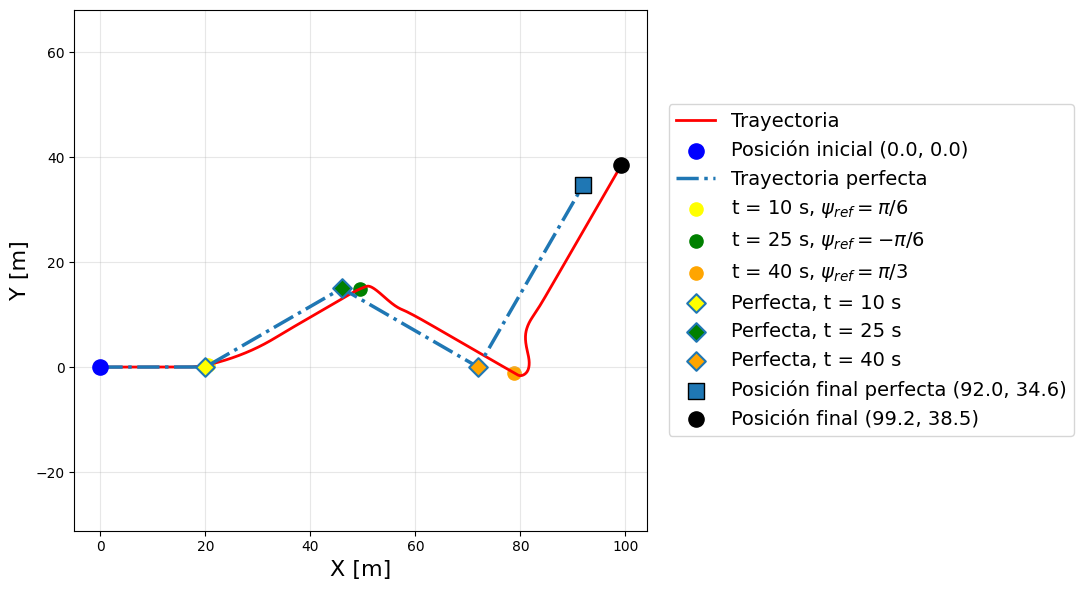

In [12]:
fontsize = 16


idx_10 = np.argmin(np.abs(T - 10))
idx_25 = np.argmin(np.abs(T - 25))
idx_40 = np.argmin(np.abs(T - 40))

# Trayectoria perfecta: psi sigue a psi_ref instantaneamente y no hay deriva lateral (v = 0).
dt = np.diff(T)
X_perfect = np.concatenate(([X[0]], X[0] + np.cumsum(u0 * np.cos(psi_ref[:-1]) * dt)))
Y_perfect = np.concatenate(([Y[0]], Y[0] + np.cumsum(u0 * np.sin(psi_ref[:-1]) * dt)))

colors = ['yellow', 'green', 'orange']



plt.figure(figsize=(11, 6))
plt.plot(X, Y, color='red', linewidth=2, label='Trayectoria')
plt.scatter(X[0], Y[0], color='blue', s=120, label=f'Posición inicial ({X[0]:.1f}, {Y[0]:.1f})', zorder=3)

plt.plot(X_perfect, Y_perfect, color='tab:blue', linestyle='-.', linewidth=2.5, label='Trayectoria perfecta')

plt.scatter(X[idx_10], Y[idx_10], s=90, label=r"t = 10 s, $\psi_{ref}=\pi/6$", marker='o', color=colors[0])
plt.scatter(X[idx_25], Y[idx_25], s=90, label=r"t = 25 s, $\psi_{ref}=-\pi/6$", marker='o', color=colors[1])
plt.scatter(X[idx_40], Y[idx_40], s=90, label=r"t = 40 s, $\psi_{ref}=\pi/3$", marker='o', color=colors[2])


plt.scatter(X_perfect[idx_10], Y_perfect[idx_10], s=90, label=r"Perfecta, t = 10 s", marker='D', color=colors[0], edgecolors='tab:blue', linewidths=1.5, zorder=4)
plt.scatter(X_perfect[idx_25], Y_perfect[idx_25], s=90, label=r"Perfecta, t = 25 s", marker='D', color=colors[1], edgecolors='tab:blue', linewidths=1.5, zorder=4)
plt.scatter(X_perfect[idx_40], Y_perfect[idx_40], s=90, label=r"Perfecta, t = 40 s", marker='D', color=colors[2], edgecolors='tab:blue', linewidths=1.5, zorder=4)


plt.scatter(X_perfect[-1], Y_perfect[-1], color='tab:blue', s=120, label=f'Posición final perfecta ({X_perfect[-1]:.1f}, {Y_perfect[-1]:.1f})', marker='s', edgecolors='black', linewidths=1.0, zorder=4)
plt.scatter(X[-1], Y[-1], color='black', s=120, label=f'Posición final ({X[-1]:.1f}, {Y[-1]:.1f})', zorder=3)

plt.xlabel('X [m]', fontsize=fontsize)
plt.ylabel('Y [m]', fontsize=fontsize)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend(fontsize=fontsize - 2, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
if not os.path.exists("plots"):
    os.makedirs("plots")
plt.savefig("plots/parteB_trayectoria.png", dpi=300)
plt.show()

### 4)

Para analizar el efecto de los cambios de $\psi_{ref}$ sobre la trayectoria, se marcaron sobre el gráfico $X,Y$ los instantes $t=10\,s$, $t=25\,s$ y $t=40\,s$, donde cambia la referencia de rumbo. Esto permite relacionar cada cambio de curvatura de la trayectoria con el valor de referencia aplicado en ese tramo.

En $t=25\,s$, la referencia pasa a $t=25\,s$. Este cambio de signo en el rumbo deseado hace que el controlador oriente la embarcación en sentido contrario, por lo que se observa un cambio de curvatura: la trayectoria deja de crecer hacia $Y$ positivo y comienza a descender.

Finalmente, desde $t=40\,s$, la referencia toma el valor $\pi/3$, que es el mayor ángulo solicitado. Por eso, la embarcación vuelve a girar hacia valores positivos de $Y$, generando una curva más pronunciada en el último tramo.

La trayectoria es continua, ya que el sistema no cambia de dirección de manera instantánea. Sin embargo, se observan cambios de curvatura marcados en los instantes en los que cambia la referencia. Esto ocurre porque el controlador necesita un cierto tiempo para llevar el rumbo real $\psi(t)$ al nuevo valor de referencia. Por ese motivo, después de cada cambio de $\psi_{ref}$, la embarcación realiza una transición hasta orientarse nuevamente según el rumbo pedido.

### 5)

* La posibilidad de considerar las variables X e Y como salidas controladas, y c´omo cambiar´ıa el problema de control.
* A partir de los gr´aficos pedidos, si la trayectoria recorrida es consistente con los cambios de rumbo pedidos.
* C´omo afecta la velocidad de respuesta del controlador a la trayectoria.
* C´omo afecta la velocidad lateral v(t) a la posici´on en el plano.
* Si la trayectoria representa cambios suaves o bruscos.
* Qu´e limitaciones tendr´ıa este esquema si se quisiera controlar directamente la posici´on en el plano XY.

**Posibilidad de considerar X e Y como salidas controladas**

Controlar directamente X e Y implicaría transformar el problema de un sistema SISO (entrada $\tau_r$, salida $\psi$) a un sistema MIMO con dos salidas adicionales. El problema se vuelve más complejo: la relación entre la entrada de control ($\tau_r$) y las posiciones $X$, $Y$ en el plano es no lineal, ya que depende de $\sin(\psi)$ y $\cos(\psi)$. El controlador por realimentación de estados lineal diseñado en la Parte A no es aplicable para controlar posición, y sería necesario utilizar técnicas de control no lineal o al menos linealización.

**Consistencia de la trayectoria con los cambios de rumbo**

La trayectoria obtenida es consistente con la secuencia de referencias aplicadas. Durante los primeros 10 s ($\psi_{ref} = 0$), la embarcación avanza aproximadamente en línea recta a lo largo del eje $X$. Al cambiar a $\psi_{ref} = \pi/6 \approx 30°$, la trayectoria sigue hacia valores positivos de $Y$. Al pasar a $\psi_{ref} = -\pi/6$, el rumbo cambia de signo y la trayectoria se dobla hacia valores negativos de $Y$. Finalmente, con $\psi_{ref} = \pi/3 \approx 60°$, el ángulo es mayor y la curvatura es más pronunciada, con crecimiento en $Y$.

**Efecto de la velocidad de respuesta del controlador sobre la trayectoria**

La velocidad de respuesta del controlador determina cuán rápido el rumbo $\psi(t)$ alcanza el valor de referencia. Un controlador lento (polos más cercanos al origen) genera transiciones más suaves pero implica que durante el período de convergencia la embarcación avanza con un rumbo incorrecto, produciendo desviaciones de posición. Un controlador más rápido (polos más alejados hacia la izquierda) reduce esas desviaciones, pero puede generar señales de control de mayor amplitud.

**Efecto de la velocidad lateral $v(t)$ sobre la posición en el plano**

Según las ecuaciones cinemáticas, $v(t)$ contribuye con los términos $-v\sin(\psi)$ en $\dot{X}$ y $+v\cos(\psi)$ en $\dot{Y}$. Esto significa que incluso si el ángulo de rumbo $\psi$ fuera exactamente el deseado, la presencia de $v(t)$ hace que la dirección real de desplazamiento difiera levemente de la dirección apuntada por el bote.

**Suavidad de la trayectoria**

La trayectoria es continua y no presenta discontinuidades, ya que la posición se obtiene integrando las velocidades. Sin embargo, en los instantes en que cambia $\psi_{ref}$ ($t = 10$, $25$ y $40$ s), se producen cambios de curvatura visibles. Estos reflejan el tiempo que tarda el controlador en llevar $\psi$ al nuevo valor de referencia. Con los polos seleccionados, la respuesta es razonablemente suave, sin oscilaciones pronunciadas.

**Limitaciones para controlar directamente la posición en el plano $XY$**

El esquema actual no permite controlar directamente $X$ e $Y$ por varias razones. Primero, el modelo de control es lineal y SISO, diseñado exclusivamente para regular $\psi$. Segundo, las ecuaciones cinemáticas que relacionan $\psi$ con $X$ e $Y$ son no lineales. Tercero, no existe realimentación de posición: el sistema no sabe dónde está en el plano, solo controla el rumbo.

### Guardado de resultados de la parte B

In [10]:
data_B = {
    "X": X.tolist(),
    "Y": Y.tolist(),
    "X0": float(X[0]),
    "Y0": float(Y[0]),
    "X_final": float(X[-1]),
    "Y_final": float(Y[-1])
}

path = "resultados/parteB.json"

if not os.path.exists("resultados"):
    os.makedirs("resultados")

with open(path, "w") as f:
    json.dump(data_B, f, indent=4)